# Network Science Assignment 2

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 7. October 2024

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import glob
from collections import defaultdict

In [19]:
# create accessibility helper for the given data and load it
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

## Task 1

### Plot a scatter plot with the average degree of the nearest neighbors knn(k) against the degree

* The following section calculates the average degree of the nearest neighbors knn(k) and plots them against the degree
* First, helper functions are created that can be used throughout the assignment to generate clean plots and keep the code slim
* The function "average_neighbor_degree" is the core of task 1 and determines the aggregated average degree of the nearest neighbors knn per degree

In [20]:
# adds given x, y data to a subplot (ax)
def add_to_scatter(ax, x, y, col='b', alpha=0.5, label=None):
    ax.scatter(x, y, color=col, alpha=alpha, label=label)
    ax.grid(True)

# set the labels and the title of a given subplot ax
def set_ax_labels(ax, x_label, y_label, title):
    ax.set_xlabel(f"{x_label}")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(f" {title}")

# initialize a flattened figure
def initialize_figure(COLS, ROWS):
    fig, axes = plt.subplots(ROWS, COLS, figsize=(5 * COLS, 5 * ROWS))
    axes = axes.flatten() 

    return fig, axes

# removes all unused subplots in given range
def clean_figure(fig, axes, start, end):
    for i in range(start, end):
        fig.delaxes(axes[i])


In [21]:
# The function below is the core of the given task. For each node in G the function first calculates 
# the average neighbor degree and degree. 
# The values are aggregated by degree and averaged. 
# INPUT: An nx Graph
# RETURN: The average neighbor degree per degree
def average_neighbor_degree(G):
    avg = nx.average_neighbor_degree(G)
    degree = dict(G.degree())
    avg_per_degree = defaultdict(list)

    for node, degree in degree.items():
        avg_per_degree[degree].append(avg[node])
    
    avg_per_degree = {degree: np.mean(avg_per_degree[degree]) for degree in avg_per_degree}

    return avg_per_degree

# Plots the average neighbor degree against the degree of an nx Graph on a given ax of a figure
def plot_ang_on_axis(G, ax, title=None):
    avg_per_degree = average_neighbor_degree(G)
    add_to_scatter(ax, avg_per_degree.keys(), avg_per_degree.values())
    set_ax_labels(ax, "k", "⟨knn(k)⟩", title=title)

# main function for Task 1, iterating over all datasets
def plot_ang_degree_of_graphs(data_lst):
    fig, axes = initialize_figure(4,2)

    for i, g in enumerate(data_lst):
        plot_ang_on_axis(g, axes[i], title=data_names[i])
    
    clean_figure(fig, axes, len(data_lst), len(axes))
    
    fig.suptitle("Task 1 - knn(k) vs Degree", fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.99]) 

    plt.show()


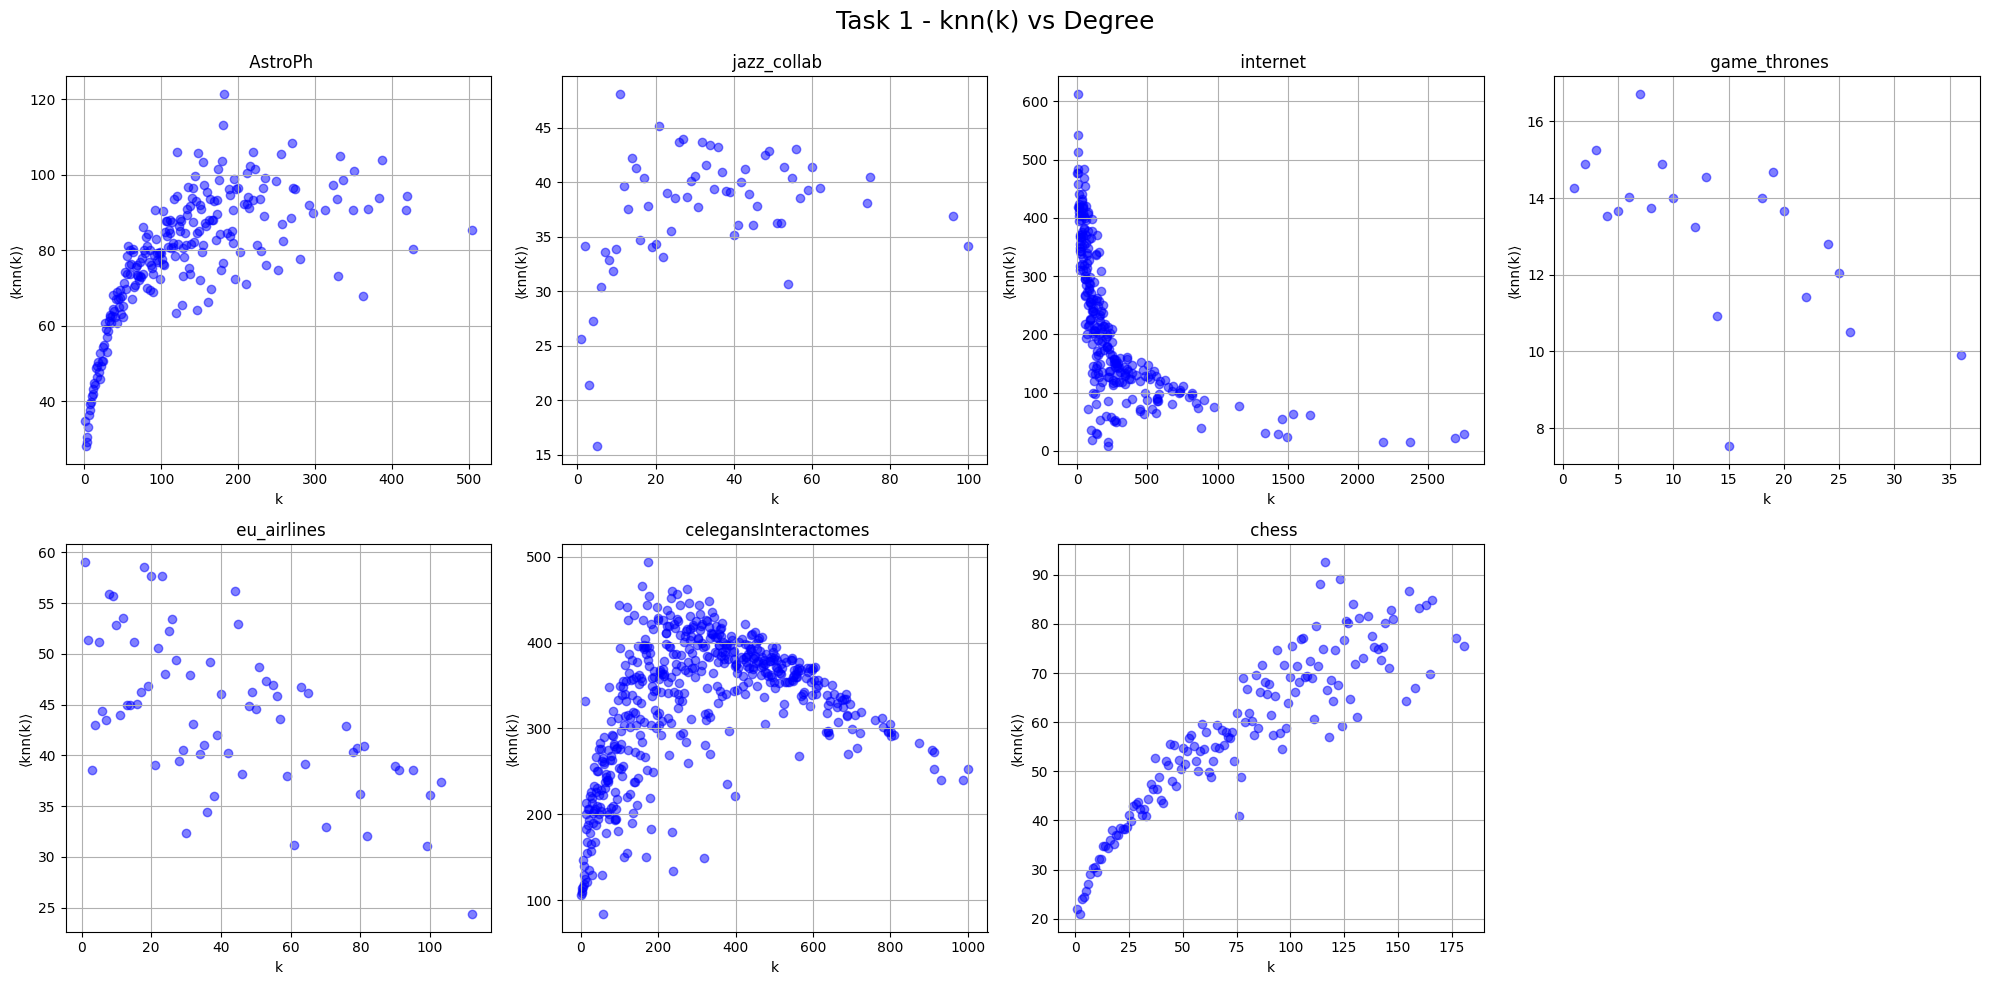

In [22]:
# plot the given network graphs
plot_ang_degree_of_graphs(data_lst)

## Task 2

### Randomized network graph

* The graphs are randomized using "nx.algorithms.smallworld.random_reference" with connectivity set to False
* By definition, this does not change the degree of a node, hence we can expect the same distribution over the x-axis 
* The original data is plotted in BLUE, while the randomized version is given in RED
* The same function for the average neighbor degree is used as for task 1


In [23]:
#randomize the given network graphs
randomized_graphs = [nx.algorithms.smallworld.random_reference(g, connectivity = False) for g in data_lst]

In [24]:
def plot_original_and_randomized(og, rg, ax, title):
    
    # original graph
    avg= average_neighbor_degree(og)
    add_to_scatter(ax, avg.keys(), avg.values(), label="Original")
    
    # randomized graph
    avg_rand = average_neighbor_degree(rg)
    add_to_scatter(ax, avg_rand.keys(), avg_rand.values(), col='r', label="Randomized")
    
    # Set labels
    set_ax_labels(ax, "k", "⟨knn(k)⟩", title=title)
    
    ax.legend()


In [25]:
# main function for Task 2, iterating over all datasets
def plot_ang_degree_comp(og, rg, title):

    fig, axes = initialize_figure(4, 2)

    for i, g in enumerate(og):
        plot_original_and_randomized(g, rg[i], axes[i], data_names[i])

    clean_figure(fig, axes, len(og), len(axes))
    
    fig.suptitle(title, fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.99])

    return fig, axes

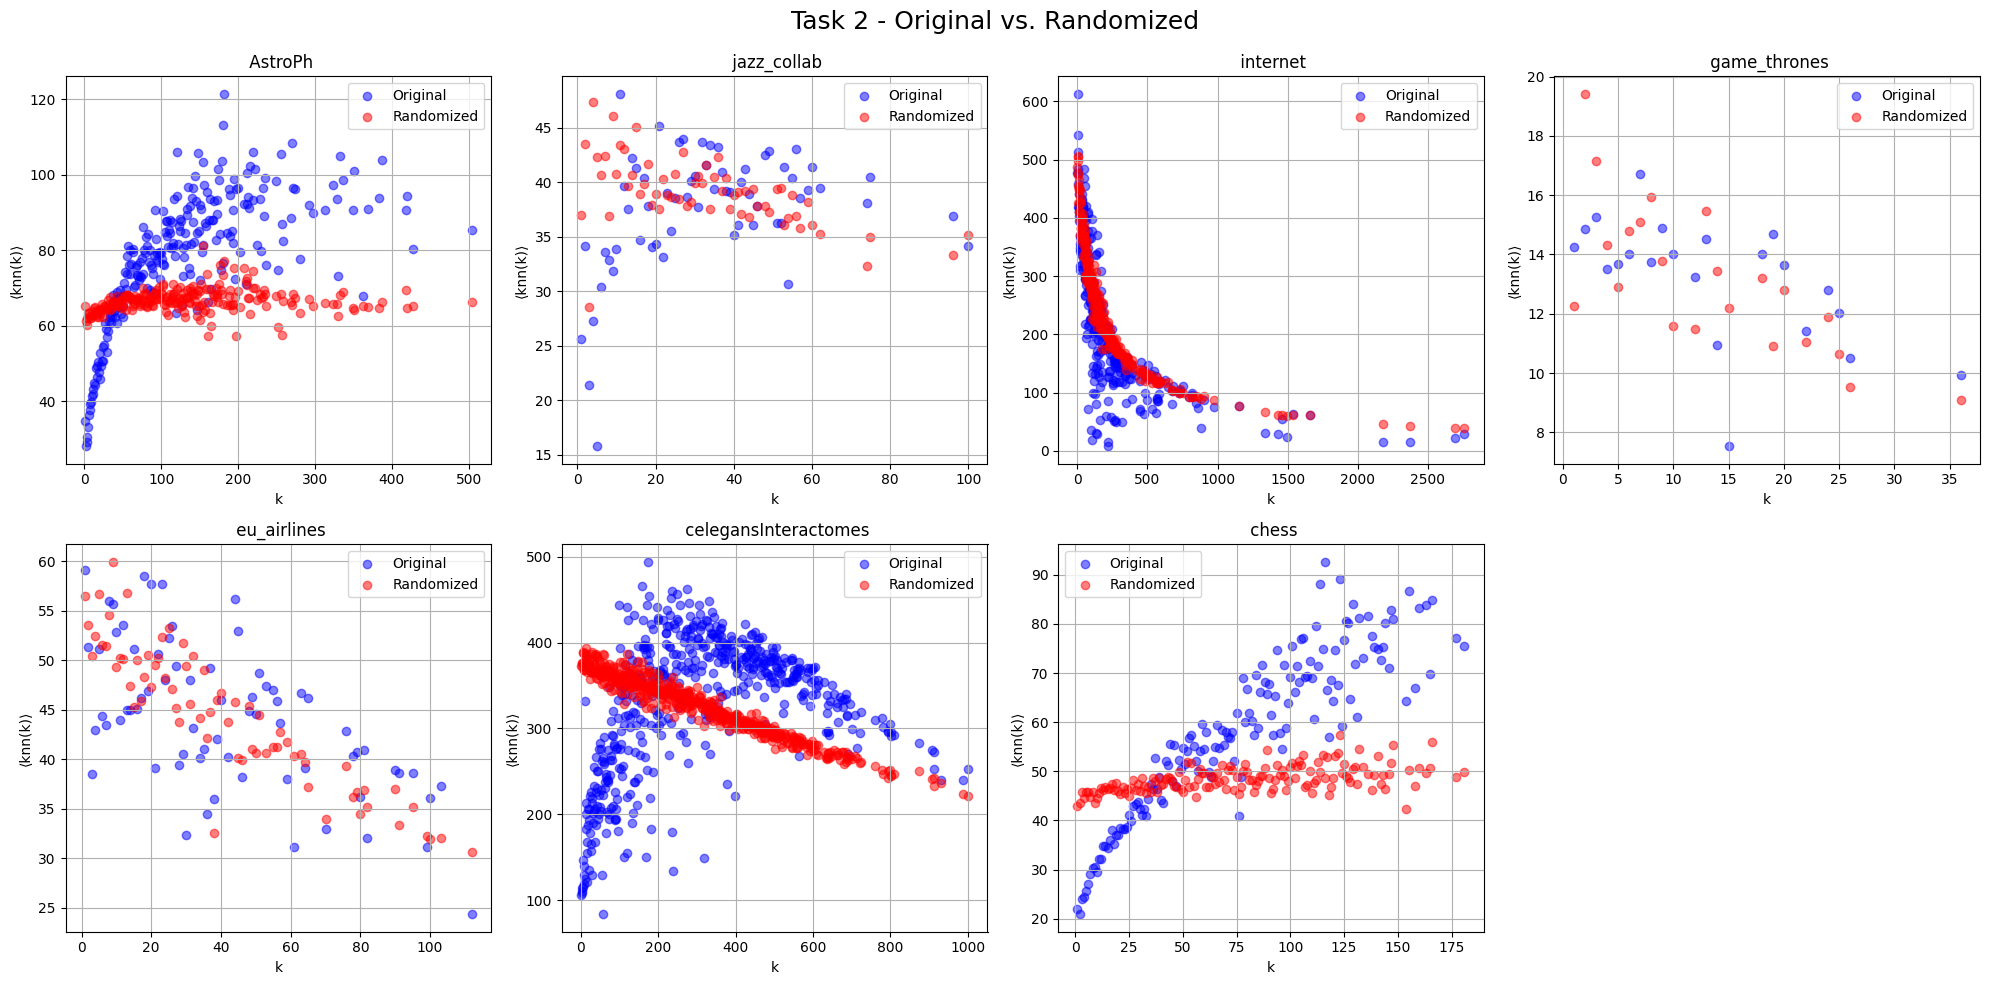

In [26]:
fig, axes = plot_ang_degree_comp(data_lst, randomized_graphs, "Task 2 - Original vs. Randomized")
plt.show()

## Task 3

### Assortativity

* In this step we add the assortativity of both the original and the randomized graphs to each plot obtained in task 2.
* Assortativity is rounded to 3 floating points. Denoted in the legend of each graph as "A: "


In [27]:
# compute the assortativity of the network graphs
def assortativity(G):
    return nx.degree_assortativity_coefficient(G)

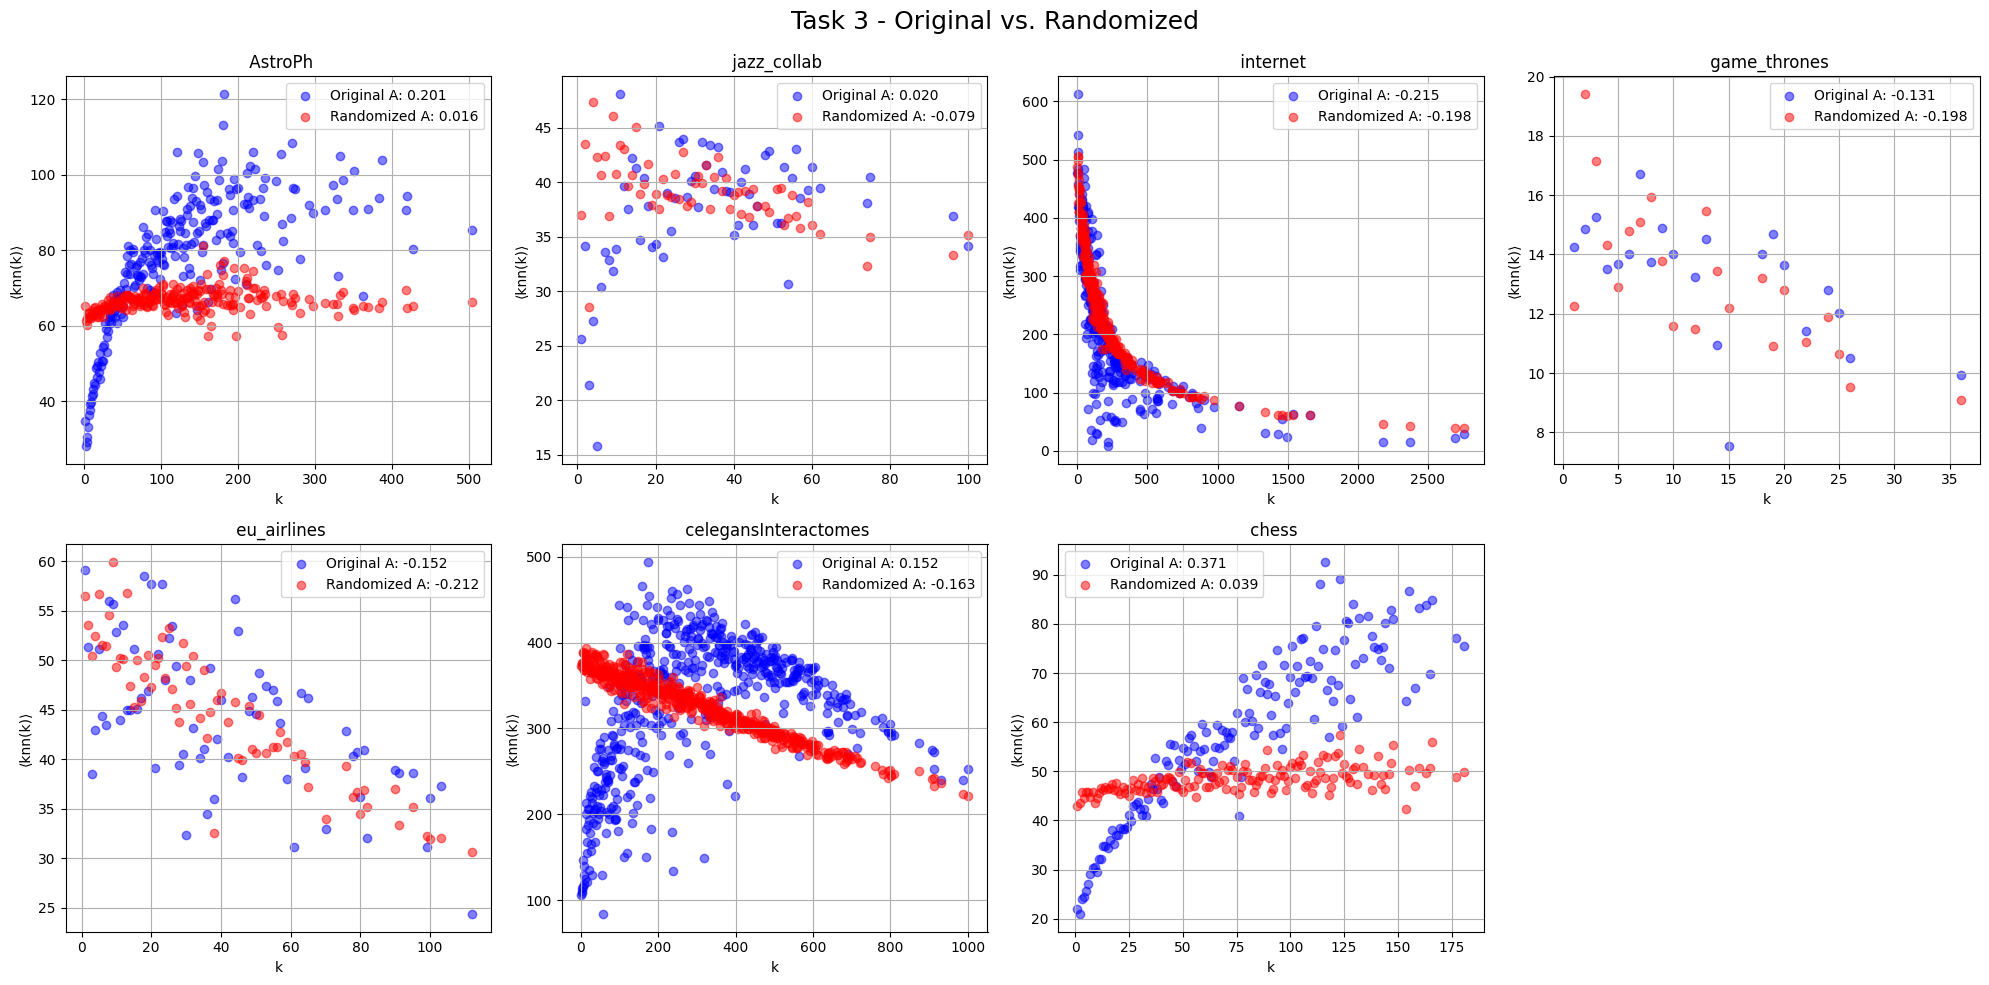

In [28]:
# first a duplicate of task 2 is generated before the labels are added
fig, axes = plot_ang_degree_comp(data_lst, randomized_graphs, "Task 3 - Original vs. Randomized")
for i,g in enumerate(data_lst):
    A_O = assortativity(g)
    A_R = assortativity(randomized_graphs[i])
    axes[i].legend([f"Original A: {A_O:.3f}", f"Randomized A: {A_R:.3f}"])
plt.show()

## Task 4


### Plotting the Degree Distribution

* we determine the degree distribution and plot in on a histogram using logarithmic binning (20 bins)

In [29]:
# plots the degree distribution against the degree using logarithmic binning
def plot_degree_dist(g, ax, title=None):
    degrees = list(dict(g.degree()).values())
    bins = np.logspace(np.log10(1), np.log10(max(degrees)), 20)

    ax.hist(degrees, bins=bins, density=True, edgecolor='black') 
    ax.set_xscale('log')
    ax.set_yscale('log')

    set_ax_labels(ax, "k", "Degree Dist (p(k))", f"{title}")


# main function for Task 4, iterating over all data
def plot_degree_distributions(data_list):
    fig, axes = initialize_figure(4,2)

    for i, g in enumerate(data_list):
        plot_degree_dist(g, axes[i], title=data_names[i])
    
    clean_figure(fig, axes, len(data_lst), len(axes))
    
    fig.suptitle("Task 4 - Degree Distributions", fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.99]) 

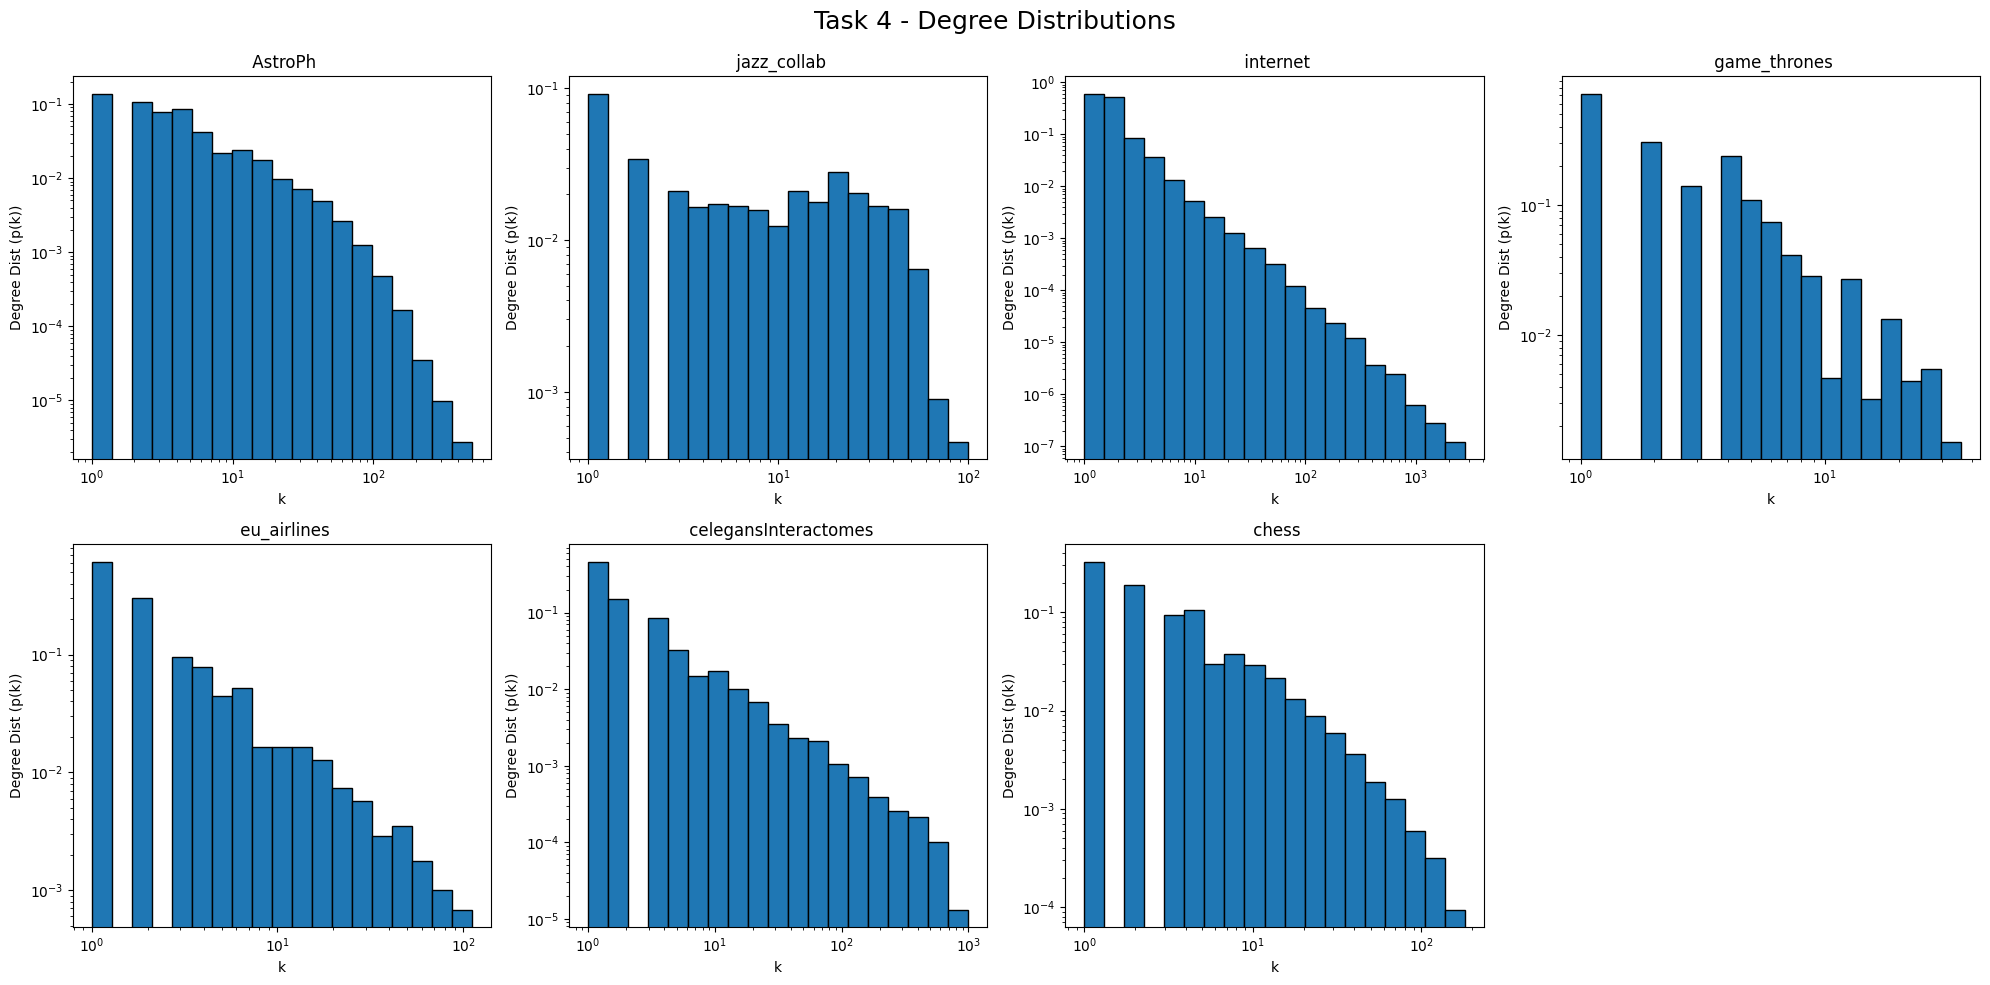

In [30]:
plot_degree_distributions(data_lst)

## Task 5 - Analysis

For each network, provide a short comment on the plots you produced in the previous 4 questions. Decide whether a Network is assortative or disassortative. Explain your rationale.

### AstroPh  

AstroPhysics Arxiv collaborations: Nodes represent authors of papers submitted to arxiv.org in the AstroPh category and Edges
represent co‑authorship between two authors

##### 1. Average Neighbor Degree vs. Degree (Plot 1)
* The average neighbor degree is clearly positively correlated with with the degree, however, this correlation is of decreasing nature. I.e. with higher degrees, this correlation gets weaker and weaker.
* However, due to the few data points available for higher degrees the exact relationship cannot be determined by solely this plot.
* Overall, plot 1 hints towards some associativity.

##### 2. Randomized Network Graph (Plot 2)
* The randomization of the network graph has severe implications for the degree connectivity. The exhibited positive trend in the original graph is no longer visible. Hence, the degree connectivity is likely not random.
* This means that the degree connectivity is not a property of the underlying degree distribution, but inherent to how the given nodes are connected in this specific network.

##### 3. Assortativity (Plot 3)
* The findings from task 1 and two are backed by the assortativity metrics. 
* The original graph has A: 0.201 while the randomized version appraoches 0 with A: 0.016.
* This hints, that it is likely for nodes with higher degree to be connected to other nodes with high degree. However, the correlation is weak, likely caused by the already discussed strongly decreasing nature of the relation for nodes with high degrees (around deg(k) > 200)

##### 4. Degree Distribution (Plot 4)
* Power Law: The degree distribution indicates few nodes with high degrees and many with low degrees.
* This is in line with the previous findings. While we exhibit some assortativity, high degree nodes are also connected to lower degree nodes

##### Brief Conclusion
* The network exhibits an overall positive assortativity (A: 0.2), not present in the randomized version, i.e. its not random/ a result inherently caused by the degree distribution. However, this assortativity seems to be decreasing with increasing degree, thus locally for high degree nodes, this relationship is weak.
* This means that highly collaborative authors are likely to work with other prominent authors, but also frequently collaborate with less connected authors. This could reflect the nature of large scientific collaborations, where established researchers co-author papers both with other established figures and with early-career scientists or specialists with fewer collaborations.


### Jazz  
Jazz collaboration network: Nodes represent jazz musicians and Edges represent collaborations in bands that performed be‑
tween 1912 and 1940

##### 1. Average Neighbor Degree vs. Degree (Plot 1)
* In the given graphic, trends are hard to decipher visually, while one might be able to see a miniscule positive relation, the small number of data points together with rather the rather wide spread, especially for low degree nodes, do not allow for a well-founded statement. 

##### 2. Randomized Network Graph (Plot 2)
* The hinted positive relation disappears when randomizing the graph, however, still no degree correlation can be determined with certainty.
* What can be said, is the the slight positive relation has switched sign and now might be slightly negative.

##### 3. Assortativity (Plot 3)
* Both findings of Plot 1 and Plot 2 are confirmend by the Assortativity. While the original graph does have a small positive assotativity (A: 0.02), the randomized version has switched sign (A: -0.07).
* Still, both factors are close enough to 0 that it is unlikely that the network exhibits as significant degree correlation 

##### 4. Degree Distribution (Plot 4)
* The degree distribution supports again the above findings. A large portion of nodes exhibits a degree around the mean. The smaller portion of nodes with very low or very high degree, do not appear to have a significant influence on the overall assortativity. I.e.

##### Brief Summary
* Both, the original and the randomized version exhibit only a small assortativity close to 0. Together with the rather centered degree distribution, the jazz network is likely neither assortative nor disassortative. In terms of the jazz networks: historically the musicians do not exhibit a strong preference for collaboration based on previous collaboration history. 

### Internet  
Internet AS graph: Nodes represent autonomous systems and Edges represent connections between them

##### 1. Average Neighbor Degree vs. Degree (Plot 1)
* Plot 1 indicates a disassortative relationship, especially for high degree nodes (deg(k) > 500). This tendency is less or not at all exhibited in lower degree nodes.

##### 2. Randomized Network Graph (Plot 2)
* The same relationship is given for the randomized network graph, indicating, that the hinted disassortiative relationship is random.
* Random in this case means that the degree connectivity is not caused by an underlying network specific property, but inherent to the degree distribution.

##### 3. Assortativity (Plot 3)
* The assumed relationship from plots 1 and 2 is confirmed by the Assortativity metrics. The one for the original graph (-0.215) and that for the randomized graph (-0.198) are very close.

##### 4. Degree Distribution (Plot 4)
* Power Law: The degree distribution shows what was to be expected for a graph with the above outlined assortativities. The internet has few highly connected nodes (high degree) that function as "hubs". Less connected nodes tend to be connected to these hubs. 

##### Brief Summary
* The analysis shows that the Internet AS graph exhibits a disassortative mixing pattern, especially for high-degree nodes, suggesting that hubs connect to many low-degree nodes. 
* This pattern is largely inherent to the network's degree distribution, as evidenced by the similar behavior in the randomized network, and the negative assortativity coefficients confirm the weak correlations between nodes of similar degree.
* This disassortative mixing pattern suggests that highly connected hubs (major networks or providers) tend to connect to many smaller, less-connected systems, promoting efficient and hierarchical routing across the global internet.


### Game of Thrones  
Game of Thrones co‑appearances: Nodes represent Game of Thrones characters and Edges represent co‑appearances of char‑
acters in the Game of Thrones series

##### 1. Average Neighbor Degree vs. Degree (Plot 1)
* Plot 1 shows somewhat negative trend, where the average neighbor degree decreases as node degree increases. 
* This indicates a disassortative mixing pattern, or in term of the network: Supporting characters tend to interact with main characters.

##### 2. Randomized Network Graph (Plot 2)
* The randomized network graph retains the disassortative mixing pattern, and appears highly similar to the original graph.
* This hints that the given connectivity is caused by the degree distribution rather than another network specific factor.

##### 3. Assortativity (Plot 3)
* The randomized version has an even more pronounced disassortative property (-0.21) that the original (-0.13).
* This might indicate that while supporting characters often appear together with main characters, the same is true for main characters. However, latter also appear frequently with other major characters.

##### 4. Degree Distribution (Plot 4)
* Power Law: The degree distribution shows again what the previous analysis already hinted towards. The network has a high number of low degree nodes (supporting characters) and only few with high degree (main characters)

##### Brief Summary
* The Game of Thrones co-appearance network exhibits a disassortative mixing pattern, where supporting characters tend to interact with main characters. The randomized network maintains a similar structure, indicating that this pattern is largely driven by the degree distribution.
* The fact that the dissassortativity of the original network is less pronounced is likely due to the fact that main characters also co-appear with other major characters.


### EU Airlines  
European airline network: Nodes represent airlines and Edges represent airline routes among European airports. 

##### 1. Average Neighbor Degree vs. Degree (Plot 1)
* Again, plot 1 exhibits a disassortative mixing pattern.
* This means that the less connected airlines tend to connect to hubs, i.e airlines with far outreach. 

##### 2. Randomized Network Graph (Plot 2)
* The dissassortative pattern is confirmed by the randomized graph. I.e. it indicates that its an inherent property of the degree distribution of the network. 

##### 3. Assortativity (Plot 3)
* The assortativity measures confirm the above outline properties. Both the original (-0.15) and the randomized network (-0.20) are disassortative and the magnitudes are close.

##### 4. Degree Distribution (Plot 4)
* Power Law: The degree distribution shows what is to be expected in the avaiation industry. Few highly connected players (international/ global airlines) with many smaller/medium regional airlines. 

##### Brief Summary
* The European airline network shows a disassortative mixing pattern, with smaller airlines connecting to large hubs, driven by the degree distribution.
* The assortativity metric and the degree distribution confirm the dominance of a few highly connected EU (likely global) airlines and many smaller regional ones.

### Celegans  
C. elegans interactomes: Nodes represent proteins and Edges represent protein‑protein interactions in Caenorhabditis elegans
(nematode).

##### 1. Average Neighbor Degree vs. Degree (Plot 1)
* The mirrored (along x-ayis) "L-like" shape of the original data hints to an assortative distribution for small degree nodes (deg(k) < 100).
* This trend flips for higher degree nodes (deg(k) < 400), where the the degree connectivity is disassortative.

##### 2. Randomized Network Graph (Plot 2)
* The randomized network graph has a completely different pattern. The randomized graph is strongly and linearly disassortative.

##### 3. Assortativity (Plot 3)
* The assortativity metric paints a clearer picture for the original and the randomized network.
* As expected, the randomized version is disassortative (A: -0.16).
* The original on the other hand is globally assortative (A: 0.15). Due to the given shape, this was hardly visble in plot 1.
* This discrepancy between the two versions, indicates that the degree connectivity is not caused by the underlying degree distribution of the network, but inherent to protein-protein interactions.

##### 4. Degree Distribution (Plot 4)
* Power Law: As in many analyzed networks, the protein network is dominated by many low degree nodes, with only few high degree nodes. 

##### Brief Summary
* The protein network has a both assortative and disassortative properties. Note: globally assortative (A: 0.15)
* High-degree nodes, however, seem to interact with many lower-degree nodes, while low-degree nodes are broadly connected to other low-degree nodes, indicating a complex network structure.
* Thus, while we see some "hub"-like behavior at the high degree end, the assortativity of primarily low/mid-degree nodes, shows that more complex behavior is underlying the network on protein-protein interaction. 

### Chess  
Kaggle chess players: Nodes represent chess players and Edges represent chess match among the world’s top chess players

##### 1. Average Neighbor Degree vs. Degree (Plot 1)
* This plot indicates strong assortative mixing.
* This means that matches most often occur between players with a similar activity

##### 2. Randomized Network Graph (Plot 2)
* The randomization leads to a significant decrease in assortativity. 
* While a slight positive degree correlation is exhibited, it is less pronounced than in the original network graph.

##### 3. Assortativity (Plot 3)
* The assortativity metircs are as expected positive for both the original and randomized network graph. However, while the one in the randomized version is nearly negligible (A: 0.03), the original one is significant (A: 0.37)
* This discrepancy shows that the pairing of players is not based on the degree distribution, but caused by an inherent property of player pairing, such that highly active players tend to play other highly active players.

##### 4. Degree Distribution (Plot 4)
* The distribution follows once more the power law. Most players only played few games, with some high degree players with significantly more activity.

##### Brief Summary 
* The chess network exhibits strong assortativity, driven by the underlying logic of player pairing, where highly active players tend to compete against others with similar levels of activity, rather than being a result of the degree distribution.
* Given that chess players are typically matched based on similar skill levels (ELO ratings), and the number of players decreases as skill level increases, it is likely that a player's degree (activity) correlates with their ELO, though this may not hold in every case.
* Together, this creates a hierarchical structure in the network, where very active (and likely highly skilled) players predominantly play against other highly active players, reinforcing the assortative mixing pattern.


## Task 6

Find a dataset representing a disassortative or assortative network. Provide a clear description
of the network’s origin and nature, and explain why your network would exhibit assortative/disassortative behavior

### Texas Road Network [1]

The following dataset contains data on the Texas road network, given as an edge list. Intersections and endpoints are represented by nodes, and the roads connecting these intersections or endpoints are represented by undirected edges.

[1] J. Leskovec, K. Lang, A. Dasgupta, M. Mahoney. Community Structure in Large Networks: Natural Cluster Sizes and the Absence of Large Well-Defined Clusters. Internet Mathematics 6(1) 29--123, 2009.

In [31]:
# The graph is given as an edge- list. Hence we create an empty nx Graph and add 
# each edge line by line

G = nx.Graph()

# Read the edge list
with open('data/roadNet-TX.txt', 'r') as f:
    for line in f:
        # Skip comments
        if line.startswith("#"):
            continue
        # Split the line into source and target nodes
        source, target = map(int, line.split())
        G.add_edge(source, target)


# we pre-compute the randomized version of graph G as in Task 2
RG = nx.algorithms.smallworld.random_reference(G, connectivity = False)

### Analysis

* The below analysis follows the steps in tasks 1 to 4, plotted in the same figure

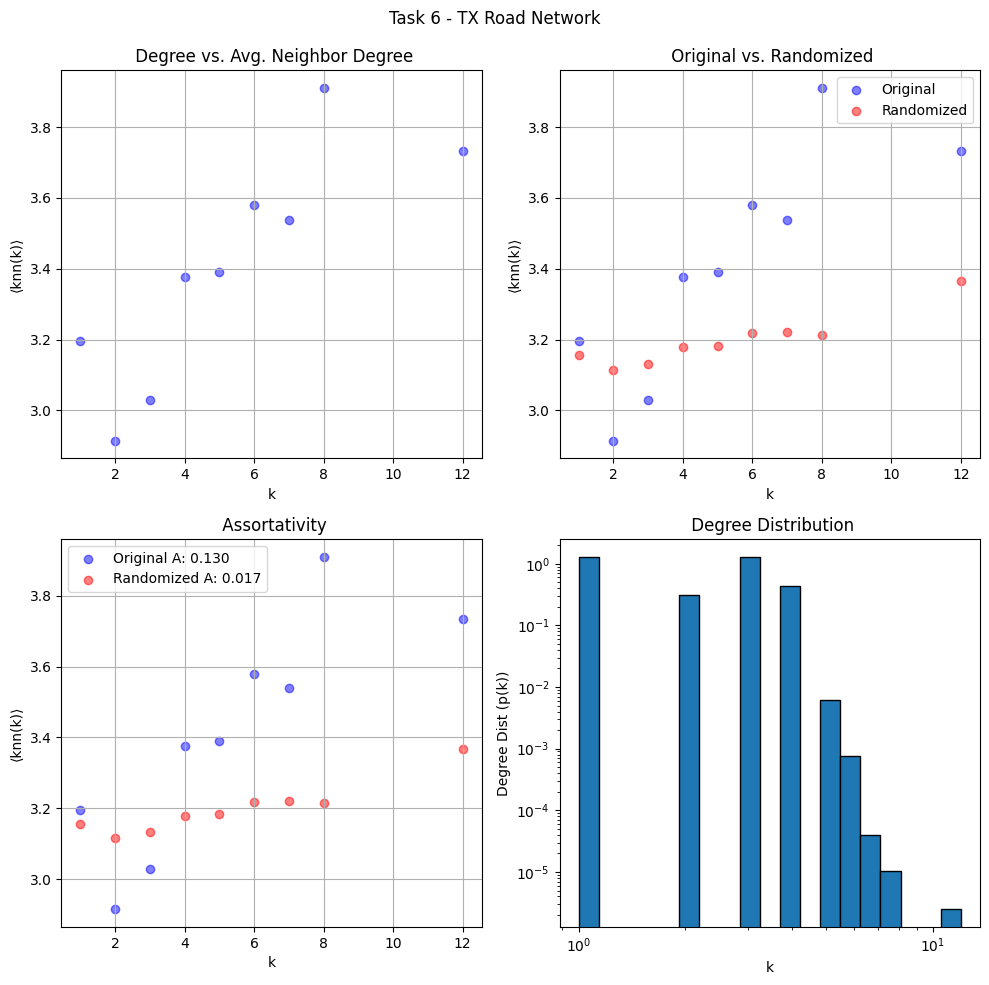

In [32]:

fig, axes = initialize_figure(2,2)
fig.suptitle("Task 6 - TX Road Network")

plot_ang_on_axis(G, axes[0], "Degree vs. Avg. Neighbor Degree")

plot_original_and_randomized(G, RG, axes[1], "Original vs. Randomized")

plot_original_and_randomized(G, RG, axes[2], "Assortativity")
A_O = assortativity(G)
A_R = assortativity(RG)
axes[2].legend([f"Original A: {A_O:.3f}", f"Randomized A: {A_R:.3f}"])

plot_degree_dist(G, axes[3], "Degree Distribution")

fig.tight_layout(rect=[0,0,1,0.99])


##### 1. Average Neighbor Degree vs. Degree (Plot 1)
* The Texas road network exhibits a slight assortative degree distribution
* Despite the apparent assortative structure, the scale of the effect is small (y-axis), suggesting that while some assortativity exists, it is not a dominant feature of the network.

##### 2. Randomized Network Graph (Plot 2)
* The randomization brings some light into the before mention marginality of the assortativity. While it appears to be only small in the original graph, the assortativity is not at all exhibited in the randomized version. This indicates some underlying structural property independent of the degree distribution to be influencing the network. In the case of a road network, the design process is likely the cause, to optimize traffic flow. 

##### 3. Assortativity (Plot 3)
* The described tendencies are confirmed by the assortativity metrics. 
* The unaltered graph is indeed assortative (A: 0.13)
* This property is no longer significantly present in the randomized graph (0.017)
* This suggests that intersections (nodes) are more likely to connect with similarly busy intersections. 

##### 4. Degree Distribution (Plot 4)
* As to be expected, the transport network contains primarily lower degree nodes, i.e. endpoints (10^0) or intersection with only few roads (2, 3 or 4). While higher degree intersections do exists, they are significantly less common.


##### Brief Summary 
* The Texas road network shows a structure where most roads (edges) connect low-degree intersections (nodes), and few major intersections handle significant traffic flow. The slight assortative nature suggests that higher-degree intersections play a critical role in maintaining efficient traffic distribution. When randomized, the network loses this property, indicating that the observed assortative structure is not random but rather a product of intentional design and planning.

